# 🤖 2. Selective Preprocessing - Classification model with Dropouts
**Deep learning model for blue fundus eye pictures classification**

The purpose of this notebook is to evaluate the binary myopia classification model across different selective preprocessing scenarios.

The classification target is derived from the spherical equivalent value:

- `class_label = 1`: myopic eye, defined as `target_SE <= -0.50 D`
- `class_label = 0`: non-myopic eye, defined as `target_SE > -0.50 D`

The same lightweight CNN architecture is trained on four preprocessing scenarios:

A. Normalization only
- With RGB conversion and normalization to [0–1].
- No geometry: no circle detection, nor padding/resizing (only dataloader resizer for 224×224 pixels).
- No CLAHE.
- No Augmentations.

B. Geometry + Normalization
- With RGB conversion and normalization to [0–1].
- With geometry: fundus circle detection + circular crop + padding to square + resizing to 224×224.
- No CLAHE.
- No Augmentations.

C. Geometry + Normalization + Illumination (no Augmentantions)
- With RGB conversion and normalization to [0–1].
- With geometry: fundus circle detection + circular crop + padding to square + resizing to 224×224.
- With CLAHE (luminance or blue can be chosen).
- No Augmentations.

D. Geometry + Normalization + Augmentations (no illumination)
- With RGB conversion and normalization to [0–1].
- With geometry: fundus circle detection + circular crop + padding to square + resizing to 224×224.
- No CLAHE.
- With geometric Augmentations: flip, light rotation and zoom applied at dataloader.

## ⚙️ 1. Setting up



In [1]:
from pathlib import Path #useful since it makes path use easier (can append paths and more)
import os, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import importlib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# from sklearn.model_selection import train_test_split - not necessary now, we will import splits
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report
)

# Load configurable project paths ============================================================

# Project root detection
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "config.yaml").exists():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise FileNotFoundError("config.yaml was not found. Make sure it is located in the project root.")
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

importlib.invalidate_caches()

from src.paths import (
    load_config,
    get_paths,
    validate_main_structure,
    print_paths
)

cfg = load_config(PROJECT_ROOT / "config.yaml")

paths = get_paths(cfg)
validate_main_structure(paths)

# General settings ===========================================================

SEED = int(cfg["settings"]["seed"])
IMG_SIZE = tuple(cfg["settings"]["image_size"]) #from config.yaml - must match the preprocessed size
BATCH = int(cfg["settings"]["batch_size"]) #from config.yaml - number of images preprocessed in each training step
AUTOTUNE = tf.data.AUTOTUNE #allows for paralelism automation

tf.keras.utils.set_random_seed(SEED)  #locks Python, NumPy and TF seed
tf.config.experimental.enable_op_determinism() #makes same deterministic ops

# Paths ===========================================================

IMAGES_DIR = paths["images"]
TABLES_DIR = paths["tables"]
SPLITS_DIR = paths["splits"]
MODELS_DIR = paths["models"]

for folder in [IMAGES_DIR, TABLES_DIR, SPLITS_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Images dir:", IMAGES_DIR)
print("Tables dir:", TABLES_DIR)
print("Splits dir:", SPLITS_DIR)
print("Models dir:", MODELS_DIR)
print("IMG_SIZE:", IMG_SIZE)
print("BATCH:", BATCH)
print("SEED:", SEED)

Project root: C:\Users\paula\0B_TFGBiomed_Exe
Images dir: C:\Users\paula\0B_TFGBiomed_Exe\Images
Tables dir: C:\Users\paula\0B_TFGBiomed_Exe\Tables
Splits dir: C:\Users\paula\0B_TFGBiomed_Exe\Splits
Models dir: C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave
IMG_SIZE: (224, 224)
BATCH: 32
SEED: 42


In [2]:
# Selective preprocessing output folders ===========================================================

SPLIT_ROOT = SPLITS_DIR / "Classification" / "SelectivePreproc"
MODELS_DIR_SELECTIVE = MODELS_DIR / "WithDropout" / "SelectivePreproc" / "Classification"

SPLIT_ROOT.mkdir(parents=True, exist_ok=True)
MODELS_DIR_SELECTIVE.mkdir(parents=True, exist_ok=True)

print("Split root:", SPLIT_ROOT)
print("Models selective output:", MODELS_DIR_SELECTIVE)

Split root: C:\Users\paula\0B_TFGBiomed_Exe\Splits\Classification\SelectivePreproc
Models selective output: C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\WithDropout\SelectivePreproc\Classification


In [3]:
# Paths to selectively preprocessed sets of images
SCENARIO_TABLES = {
    "A_Raw_minimal": TABLES_DIR / "MatchTables" / "TablaMatch_SCENARIO.A.xlsx",         # Raw with minimal preproc
    "B_GeoNorm": TABLES_DIR / "MatchTables" / "TablaMatch_SCENARIO.B.xlsx",             # geometry + normalization
    "C_GeoNorm_Illum_NoAug": TABLES_DIR / "MatchTables" / "TablaMatch_SCENARIO.C.xlsx", # geometry + normalization + illumination 
    "D_GeoNorm_Aug_NoIllum": TABLES_DIR / "MatchTables" / "TablaMatch_SCENARIO.B.xlsx" # geometry + normalization + augmentations - there is no such path, will be using B for D
}

EXPERIMENTS = [ # (name, data_root, augment_in_loader, normalization)
    {
        "name": "A_Raw_minimal",
        "table": SCENARIO_TABLES["A_Raw_minimal"],
        "do_aug": False,
        "normalization": "0-1"
    },
    {
        "name": "B_GeoNorm",
        "table": SCENARIO_TABLES["B_GeoNorm"],
        "do_aug": False,
        "normalization": "0-1"
    },
    {
        "name": "C_GeoNorm_Illum_NoAug",
        "table": SCENARIO_TABLES["C_GeoNorm_Illum_NoAug"],
        "do_aug": False,
        "normalization": "0-1"
    },
    {
        "name": "D_GeoNorm_Aug_NoIllum",
        "table": SCENARIO_TABLES["D_GeoNorm_Aug_NoIllum"], #makes use of geom+norm to make augmentations without illumination
        "do_aug": True,
        "normalization": "0-1"
    }
]

for name, path in SCENARIO_TABLES.items():
    print(name, "exists:", path.exists(), "|", path)
    assert path.exists(), f"Missing scenario table: {path}"

A_Raw_minimal exists: True | C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\TablaMatch_SCENARIO.A.xlsx
B_GeoNorm exists: True | C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\TablaMatch_SCENARIO.B.xlsx
C_GeoNorm_Illum_NoAug exists: True | C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\TablaMatch_SCENARIO.C.xlsx
D_GeoNorm_Aug_NoIllum exists: True | C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\TablaMatch_SCENARIO.B.xlsx


The dataset contains **2,126 valid images** for the classification task. The class distribution is clearly imbalanced: **1,645 normal images** and **481 myopic images**. This means that the normal class represents approximately **77%** of the dataset, while the myopic class represents around **23%**.

This imbalance is important because a model predicting all images as normal would already obtain a relatively high accuracy. Therefore, in this notebook, **accuracy alone should not be used as the main indicator of performance**. Metrics such as **AUC**, **Average Precision**, the **Precision-Recall curve** and the **confusion matrix** are more informative, especially because the clinically relevant class is the minority class: myopia.

The fact that the dataset is imbalanced also justifies the later use of class weights during training. However, these weights may also influence the decision threshold and can make the model more likely to classify images as myopic.

## 🛠️  2. Helpers preparation

To keep the codebase clean and efficient, several helper functions were implemented.  
These functions encapsulate small, reusable tasks that will be required multiple times throughout the preprocessing pipeline.

####  2.1 Reading the tables

In [4]:
base_df = pd.read_excel(SCENARIO_TABLES["A_Raw_minimal"])

# Keep only rows with valid paths and classification labels
base_df = base_df[base_df["image_path"].notna()].copy()
base_df = base_df[base_df["filename"].notna()].copy()
base_df = base_df[base_df["class_label"].notna()].copy()

base_df["filename"] = base_df["filename"].astype(str)
base_df["patient_id"] = base_df["patient_id"].astype(str).str.upper().str.strip()
base_df["class_label"] = pd.to_numeric(base_df["class_label"], errors="coerce").astype("Int64")

base_df = base_df.dropna(
    subset=["image_path", "filename", "patient_id", "class_label"]
).copy()

base_df["class_label"] = base_df["class_label"].astype("int32")

print("Total valid images for classification:", len(base_df))

print("\nClassification label balance:")
print(base_df["class_label"].value_counts())

base_df.head()

Total valid images for classification: 2126

Classification label balance:
class_label
0    1645
1     481
Name: count, dtype: int64


,image_path,filename,patient_id,image_date_raw,image_date,modality,eye,nhc,FechaNacimiento,Edad,...,match_type,target_SE,class_label,original_image_path,preprocessing,image_size,detect_fundus,pad_and_resize,clahe_applied,clahe_mode
0,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6138_17092024_165654_Color_R_001.jpg,A6138,17092024,2024-09-17,Color,R,A6138,2020-06-03,6,...,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none
1,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6138_17092024_165721_Color_L_001.jpg,A6138,17092024,2024-09-17,Color,L,A6138,2020-06-03,6,...,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none
2,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6140_11122023_191157_IR_R_001.jpg,A6140,11122023,2023-12-11,IR,R,A6140,1975-10-06,51,...,id+date,-2.250,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none
3,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6140_11122023_191221_IR_L_001.jpg,A6140,11122023,2023-12-11,IR,L,A6140,1975-10-06,51,...,id+date,-0.625,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none
4,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6142_12042023_153339_Color_R_001.jpg,A6142,12042023,2023-04-12,Color,R,A6142,2000-07-08,26,...,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none


#### ✂️  2.2 Splitting the dataset

A single stratified 80/10/10 split is obtained from the clinical match tables.

In [5]:
# Stratified 80/10/10 split based on class_label loaded from 00_CreatePatientLevelSplits_Classf_Regrss.ipynb

def load_existing_scenario_split(scenario_name: str) -> dict:
    scenario_split_dir = SPLIT_ROOT / scenario_name

    train_csv = scenario_split_dir / "train.csv"
    val_csv   = scenario_split_dir / "val.csv"
    test_csv  = scenario_split_dir / "test.csv"

    for csv_path in [train_csv, val_csv, test_csv]:
        if not csv_path.exists():
            raise FileNotFoundError(
                f"Missing split file: {csv_path}. "
                "Run 00_CreatePatientLevelSplits_Classf_Regrss.ipynb first."
            )

    return {
        "train": train_csv,
        "val": val_csv,
        "test": test_csv,
    }


def check_no_overlap(train_df, val_df, test_df, column: str, name: str) -> None:
    train_values = set(train_df[column].astype(str))
    val_values   = set(val_df[column].astype(str))
    test_values  = set(test_df[column].astype(str))

    assert len(train_values & val_values) == 0, f"{name}: overlap between train and val"
    assert len(train_values & test_values) == 0, f"{name}: overlap between train and test"
    assert len(val_values & test_values) == 0, f"{name}: overlap between val and test"

    print(f"OK: no {name} overlap across train/val/test.")


SCENARIO_SPLITS = {}

for exp in EXPERIMENTS:
    name = exp["name"]
    SCENARIO_SPLITS[name] = load_existing_scenario_split(name)

    train_df = pd.read_csv(SCENARIO_SPLITS[name]["train"])
    val_df   = pd.read_csv(SCENARIO_SPLITS[name]["val"])
    test_df  = pd.read_csv(SCENARIO_SPLITS[name]["test"])

    print(f"\n===== {name} =====")
    print("Train:", len(train_df))
    print("Val:  ", len(val_df))
    print("Test: ", len(test_df))

    check_no_overlap(train_df, val_df, test_df, "patient_id", f"{name} patient")
    check_no_overlap(train_df, val_df, test_df, "image_path", f"{name} image")

    print("\nTrain class balance:")
    print(train_df["class_label"].value_counts())

    print("\nVal class balance:")
    print(val_df["class_label"].value_counts())

    print("\nTest class balance:")
    print(test_df["class_label"].value_counts())


===== A_Raw_minimal =====
Train: 1701
Val:   211
Test:  214
OK: no A_Raw_minimal patient overlap across train/val/test.
OK: no A_Raw_minimal image overlap across train/val/test.

Train class balance:
class_label
0    1313
1     388
Name: count, dtype: int64

Val class balance:
class_label
0    165
1     46
Name: count, dtype: int64

Test class balance:
class_label
0    167
1     47
Name: count, dtype: int64

===== B_GeoNorm =====
Train: 1701
Val:   211
Test:  214
OK: no B_GeoNorm patient overlap across train/val/test.
OK: no B_GeoNorm image overlap across train/val/test.

Train class balance:
class_label
0    1313
1     388
Name: count, dtype: int64

Val class balance:
class_label
0    165
1     46
Name: count, dtype: int64

Test class balance:
class_label
0    167
1     47
Name: count, dtype: int64

===== C_GeoNorm_Illum_NoAug =====
Train: 1701
Val:   211
Test:  214
OK: no C_GeoNorm_Illum_NoAug patient overlap across train/val/test.
OK: no C_GeoNorm_Illum_NoAug image overlap across t

The train/validation/test split was correctly loaded for the four preprocessing scenarios. Each scenario contains the same number of samples: **1,701 images for training**, **211 for validation** and **214 for testing**. The class distribution is also preserved across the splits: the test set contains **167 normal images** and **47 myopic images**.

The checks confirm that there is **no patient overlap** and **no image overlap** between train, validation and test sets. This is essential because the same patient appearing in different subsets could artificially inflate the results. Therefore, the evaluation is more reliable than a random image-level split with possible patient leakage.

The test set is still imbalanced, with normal images representing approximately **78%** of the test set. Consequently, a majority-class baseline would obtain an accuracy of around **0.78** by always predicting normal. This baseline must be kept in mind when interpreting the test accuracies obtained by the models.


#### 🧮  2.3 Decoder and normalizer
Now we move onto building efficient TensorFlow datasets (tf.data pipeline) from image paths and labels, applying decoding, resizing, batching, and lightweight data augmentations for training. In other words, we are receiving a disk path and giving a tensor back.

Note: a tensor is the basic structure in TensorFlow (in deep learning frameworks). A picture would be a 3D tensor (hxwxchannels) and a batch of pictures would be a 4D tensor (hxwxcxbatch)

In [6]:
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406], tf.float32) #mean pixels intensity on red, green, blue channels
IMAGENET_STD = tf.constant([0.229, 0.224, 0.225], tf.float32) #standard deviations on channels

def normalize_tensor(img_float01, mode="0-1"): # Applies the selected normalization strategy
    if mode == "0-1":
        return img_float01
    if mode == "imagenet":
        return (img_float01 - IMAGENET_MEAN) / IMAGENET_STD
    if mode == "zscore":
        mean = tf.reduce_mean(img_float01, axis=[0, 1], keepdims=True)
        std = tf.math.reduce_std(img_float01, axis=[0, 1], keepdims=True) + 1e-6
        return (img_float01 - mean) / std

    return img_float01

def decode_img(path, label, normalization="0-1"): # Reads, decodes, resizes and normalizes one image
    img = tf.io.read_file(path) #reades pic as bytes
    img = tf.image.decode_jpeg(img, channels=3) #decodes jpg into rgb tensor
    img = tf.image.convert_image_dtype(img, tf.float32) #converts to float [0,1]
    img = tf.image.resize(img, IMG_SIZE, method="bilinear") #rescales to 224x224
    img = normalize_tensor(img, mode=normalization)

    return img, tf.cast(label, tf.float32)  #gives pic+label back so dataloader knows the class it belongs to 

#### 🎭  2.4 Dataloader with(out) Lightweight augmentations
Creating the TensorFlow dataset (dataloader) with simple geometric transformations (or not) to improve generalization and reduce overfitting.

Shuffles and augmentations will only be applied if training=True

The model uses:
- three convolutional blocks,
- max pooling after the first two convolutions,
- global average pooling,
- dropout regularization,
- and a sigmoid output neuron for binary myopia classification

In [7]:
#Declare the type of augmentations to be carried out (if wanted)
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"), #hozt flip (imitates eye flip)
    tf.keras.layers.RandomRotation(0.02), #slight rotation
    tf.keras.layers.RandomZoom(0.05), #slight random zoom
])

def make_classification_ds(csv_path, training=False, normalization="0-1", do_aug=False): # Creates a TensorFlow dataset for binary myopia classification
    split_df = pd.read_csv(csv_path) #cvs path is pic+label
    paths = split_df["image_path"].astype(str).values
    labels = split_df["class_label"].astype("float32").values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map( #applies decode_img on each image
        lambda p, y: decode_img(p, y, normalization=normalization),
        num_parallel_calls=AUTOTUNE 
    )

    if training: #if training, it shuffles (so it learns with random order) and applies augmentations 
        ds = ds.shuffle(8192, seed=SEED, reshuffle_each_iteration=True)

        if do_aug:
            ds = ds.map(
                lambda x, y: (augment(x, training=True), y),
                num_parallel_calls=AUTOTUNE #(aumentos)
            )

    ds = ds.batch(BATCH).prefetch(AUTOTUNE)  #prefetching makes pipeline faster; batch size declared up top

    return ds

#### 🟢  2.5 The classification model - small_cnn_classf

Definition of the small_cnn architecture used as a first baseline classifier. This was model small_cnn_classf on the Models_1FullPreproc.ipynb notebook.

In [8]:
def build_small_cnn_classf(input_shape=(224,224,3)):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs) #progressively extracts characteristics
    x = layers.MaxPool2D()(x) #reduces resolution and makes more compact/robust representation
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x) #zero-padding on borders so input is same size as output (in case kernel and input are different sizes?)
    x = layers.MaxPool2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x) #compacts activation maps into mean value (lees params and less overfitting than Flatten)
    x = layers.Dropout(0.3)(x) #randomly switches off 30% of neurons while training
    outputs = layers.Dense(1, activation="sigmoid")(x) #binary exit (1 is the probability of myopia)
    return keras.Model(inputs, outputs)

def compile_model_classf():
    model = build_small_cnn_classf()
    model.compile(optimizer=keras.optimizers.Adam(1e-3), #Adam optimizer with lr=1e-3
                  loss="binary_crossentropy", #adecuate for binary classification with sigmoid
                  metrics=[keras.metrics.AUC(name="auc"), "accuracy"]) #AUC and accuracy metrics
    return model

In [9]:
example_model = compile_model_classf()
example_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 93,377 (364.75 KB)

 Trainable params: 93,377 (364.75 KB)

 Non-trainable params: 0 (0.00 B)

#### ⏱️  2.6 Callbacks and weights
Training monitors (earlystopping and learning-rate) scheduling for stability and later use.

Class weights are correction factors used during training to handle class' number differences: errors when choosing the minority class are penalized more strongly, while errors on the majority class are penalized less. This ensures the model pays equal attention to both classes despite unequal sample counts.

In [10]:
def make_callbacks():
    return [ 
        keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True), #if AUC is not better after 5 epochs, goes back to previous weights
        keras.callbacks.ReduceLROnPlateau( monitor="val_auc", mode="max", factor=0.3, patience=2),#if AUC stays the same value after 2 epochs, LR gets reduced multiplying it by 0.3
    ]

def compute_weights(csv_train_path):
    train_df = pd.read_csv(csv_train_path) #Load train split
    
    classes = np.array([0,1])
    weights = compute_class_weight('balanced', classes=classes, y=train_df["class_label"].astype(int).values) #calcultes inverse weights to teh frecuency of each class
    return {0: float(weights[0]), 1: float(weights[1])} #dictionary understood by keras

#### 📦  2.7 Training and evalutation wrappers
Utility functions to make predictions on the dataset and evaluate results by stablished metrics.

In [11]:
#This function gives back true labels and predicted labels so as to calculate metrics later on
def collect_preds(model, ds): #dataset as ds
    y_true, y_score = [], [] #true labels 1 or 0; probabilities of model 0-1
    for xb, yb in ds:
        p = model.predict(xb, verbose=0).ravel()
        y_true.extend(yb.numpy().tolist())
        y_score.extend(p.tolist())
    y_true = np.array(y_true).astype(int)
    y_score = np.array(y_score).astype(float)
    return y_true, y_score

#Gives back a dictionary with: model name, AUC, AP, accuracy @50% threshold, confusion matrix and classification report
def evaluate_on_test(name, model, test_ds, threshold=0.5, show_plots=True):
    y_true, y_score = collect_preds(model, test_ds)
    y_pred = (y_score >= threshold).astype(int)

    #Metric 1: ROC / PR
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)

    #Metric 2: Confusion matrix & report
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=["Normal","Myopia"], digits=4)

    if show_plots:
        # ROC
        plt.figure(figsize=(5,4))
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
        plt.plot([0,1],[0,1],'--',alpha=0.5)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC curve – {name}")
        plt.grid(True)
        plt.legend()
        plt.show()

        # PR
        plt.figure(figsize=(5,4))
        plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Precision–Recall curve – {name}")
        plt.grid(True)
        plt.legend()
        plt.show()

        # Confusion matrix
        plt.figure(figsize=(4,3.6))
        plt.imshow(cm, cmap="Blues")
        plt.title(f"Confusion Matrix – {name}")
        plt.xticks([0,1], ["Normal","Myopia"])
        plt.yticks([0,1], ["Normal","Myopia"])
        for i in range(2):
            for j in range(2):
                plt.text(j, i, cm[i,j], ha="center", va="center")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.colorbar(fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()

    return {
        "name": name,
        "AUC": float(roc_auc),
        "AP": float(ap),
        "accuracy@0.5": float((y_pred == y_true).mean()),
        "confusion_matrix": cm,
        "report": report
    }

#### 🧪  2.8 Running the experiment
Full pipeline of model.

Each preprocessing scenario is trained independently using the same model architecture, same train/validation/test split, and same training configuration.

The only differences across experiments are:
- the image preprocessing level,
- and whether training-time augmentation is applied.

In [12]:
def run_experiment(exp, epochs=10):
    name = exp["name"]
    normalization = exp["normalization"]
    do_aug = exp["do_aug"]
    print(f"\n===== Running {name} =====")

    # 1) Splits (by root)
    #csv_name = ALIAS_SPLITS.get(name, name) #patch for D
    train_csv = SCENARIO_SPLITS[name]["train"]
    val_csv = SCENARIO_SPLITS[name]["val"]
    test_csv = SCENARIO_SPLITS[name]["test"]

    # In case B's CSVs didn't exist yet either - more patch for D
    #if not (os.path.exists(train_csv) and os.path.exists(val_csv) and os.path.exists(test_csv)):
    #    make_splits_for_root(data_root, out_prefix=csv_name, seed=SEED)
    
    # 2) Datasets
    train_ds = make_classification_ds(train_csv, training=True,  normalization=normalization, do_aug=do_aug)
    val_ds   = make_classification_ds(val_csv,   training=False, normalization=normalization, do_aug=False)
    test_ds  = make_classification_ds(test_csv,  training=False, normalization=normalization, do_aug=False)

    # 3) Model
    model = compile_model_classf()
    
    # 4) Class weights + callbacks
    class_weight = compute_weights(train_csv)
    print("Class weights:", class_weight)
    cb = make_callbacks()

    # 5) Train
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=cb, class_weight=class_weight)

    # 6) Evaluate
    test_metrics = evaluate_on_test(name, model, test_ds, show_plots=True)
    print(test_metrics["report"])
    
    return model, history, test_metrics, (train_ds, val_ds, test_ds)


## 🚀 3. The launching of the model

Now, we'll launch the binary classification (small_cnn_classf), that is CPU friendly and compiles it with Adam and binary cross-entropy, adds AUC/accuracy metrics, uses early stopping and learning-rate reduction on plateau, computes class weights from the train split, and trains the model with the tf.data pipelines.

We'll be applying it on the 4 baselines:

🇦 2.1 Small CNN with raw images - Mere normalization.

🇧 2.2 Small CNN with no Illumination and no Augmentations - This time only geometry and normalization preprocessing are applied.

🇨 2.3 Small CNN with Illumination (no augmentations) - This time only geometry, normalization and illumination preprocessing are applied.

🇩 2.4 Small CNN with Augmentations (no illumination) - This time only geometry, normalization and augmentations are applied.


===== Running A_Raw_minimal =====
Class weights: {0: 0.6477532368621478, 1: 2.1920103092783507}
Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 83s 833ms/step - accuracy: 0.5765 - auc: 0.4478 - loss: 0.6955 - val_accuracy: 0.7820 - val_auc: 0.5645 - val_loss: 0.6822 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 71s 799ms/step - accuracy: 0.7635 - auc: 0.5593 - loss: 0.7016 - val_accuracy: 0.7583 - val_auc: 0.5584 - val_loss: 0.6822 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 68s 750ms/step - accuracy: 0.5305 - auc: 0.5566 - loss: 0.6959 - val_accuracy: 0.7062 - val_auc: 0.5670 - val_loss: 0.6757 - learning_rate: 0.0010
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 68s 755ms/step - accuracy: 0.3364 - auc: 0.5458 - loss: 0.6875 - val_accuracy: 0.2559 - val_auc: 0.5480 - val_loss: 0.7028 - learning_rate: 0.0010
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 69s 742ms/step - accuracy: 0.4152 - auc: 0.5684 - loss: 0.6972 - val_accuracy: 0.6493 - val_auc: 0.5783 - val_loss: 0.6664 - 

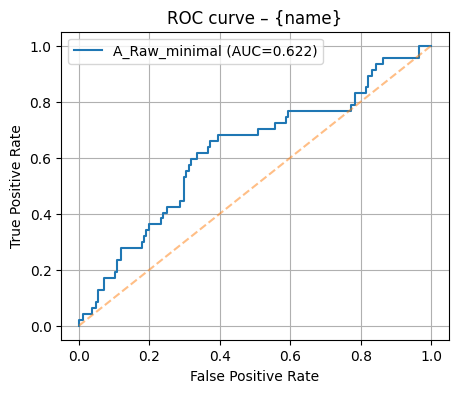

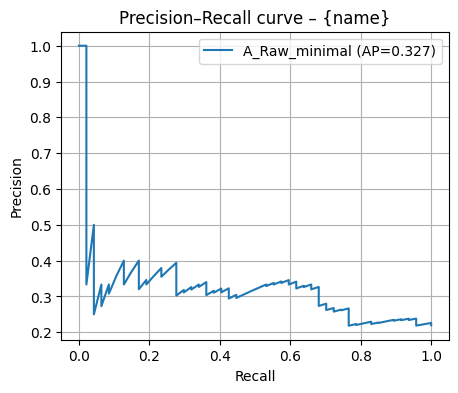

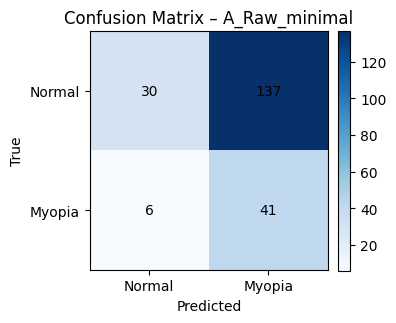

              precision    recall  f1-score   support

      Normal     0.8333    0.1796    0.2956       167
      Myopia     0.2303    0.8723    0.3644        47

    accuracy                         0.3318       214
   macro avg     0.5318    0.5260    0.3300       214
weighted avg     0.7009    0.3318    0.3107       214


===== Running B_GeoNorm =====
Class weights: {0: 0.6477532368621478, 1: 2.1920103092783507}
Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 47s 815ms/step - accuracy: 0.6146 - auc: 0.4297 - loss: 0.6977 - val_accuracy: 0.7536 - val_auc: 0.5638 - val_loss: 0.6867 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 40s 720ms/step - accuracy: 0.7261 - auc: 0.5965 - loss: 0.7000 - val_accuracy: 0.5782 - val_auc: 0.5619 - val_loss: 0.6831 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 40s 701ms/step - accuracy: 0.5249 - auc: 0.5690 - loss: 0.6940 - val_accuracy: 0.4028 - val_auc: 0.5777 - val_loss: 0.6986 - learning_rate: 0.0010
Epoch 4/10
54/54 ━━━━━━━━

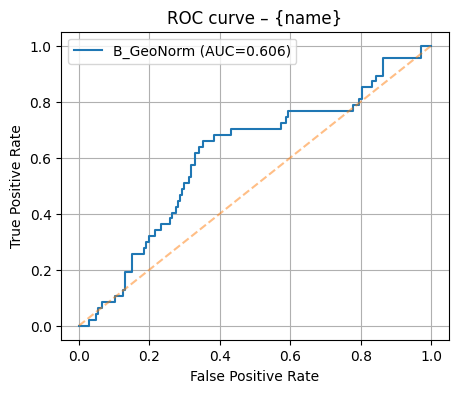

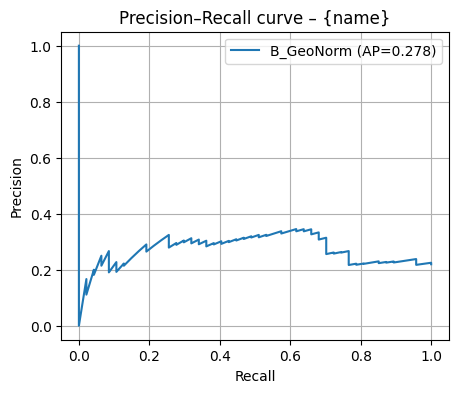

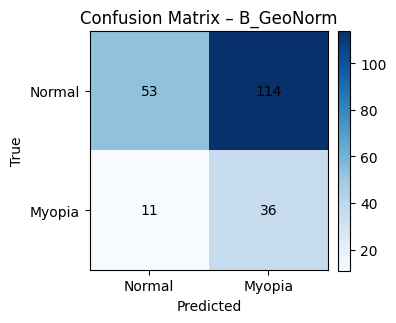

              precision    recall  f1-score   support

      Normal     0.8281    0.3174    0.4589       167
      Myopia     0.2400    0.7660    0.3655        47

    accuracy                         0.4159       214
   macro avg     0.5341    0.5417    0.4122       214
weighted avg     0.6990    0.4159    0.4384       214


===== Running C_GeoNorm_Illum_NoAug =====
Class weights: {0: 0.6477532368621478, 1: 2.1920103092783507}
Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 42s 695ms/step - accuracy: 0.5629 - auc: 0.4515 - loss: 0.6990 - val_accuracy: 0.6445 - val_auc: 0.5464 - val_loss: 0.6912 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 39s 696ms/step - accuracy: 0.5920 - auc: 0.5366 - loss: 0.7013 - val_accuracy: 0.3981 - val_auc: 0.5612 - val_loss: 0.6928 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 40s 691ms/step - accuracy: 0.3988 - auc: 0.5487 - loss: 0.6960 - val_accuracy: 0.7393 - val_auc: 0.5366 - val_loss: 0.6781 - learning_rate: 0.0010
Epoch 4/10
54

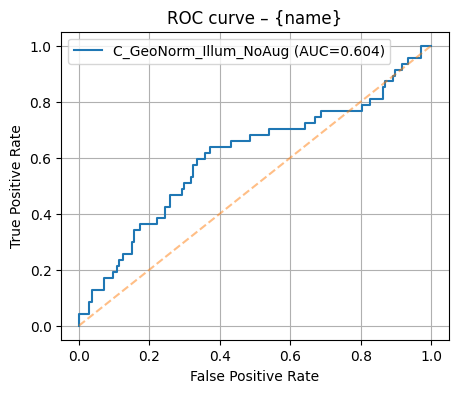

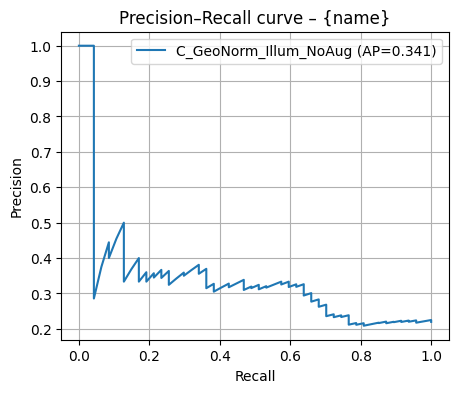

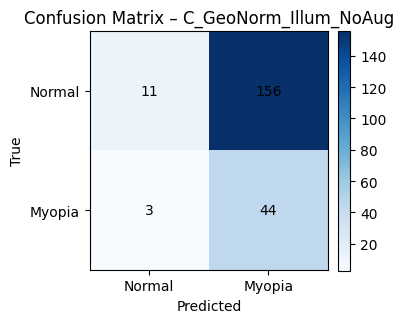

              precision    recall  f1-score   support

      Normal     0.7857    0.0659    0.1215       167
      Myopia     0.2200    0.9362    0.3563        47

    accuracy                         0.2570       214
   macro avg     0.5029    0.5010    0.2389       214
weighted avg     0.6615    0.2570    0.1731       214


===== Running D_GeoNorm_Aug_NoIllum =====
Class weights: {0: 0.6477532368621478, 1: 2.1920103092783507}
Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.5592 - auc: 0.4410 - loss: 0.6987 - val_accuracy: 0.4408 - val_auc: 0.5165 - val_loss: 0.6930 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.5243 - auc: 0.5450 - loss: 0.7008 - val_accuracy: 0.3365 - val_auc: 0.5343 - val_loss: 0.7036 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.4319 - auc: 0.5660 - loss: 0.6933 - val_accuracy: 0.3602 - val_auc: 0.5545 - val_loss: 0.7148 - learning_rate: 0.0010
Epoch 4/10
54/54 ━━━━━

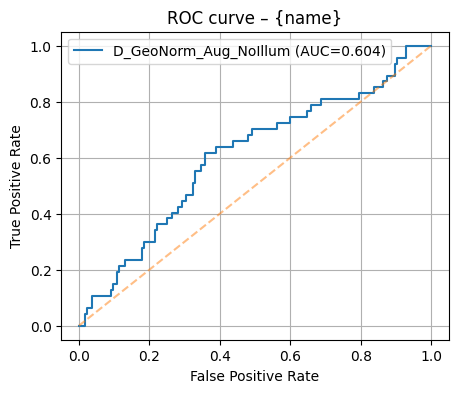

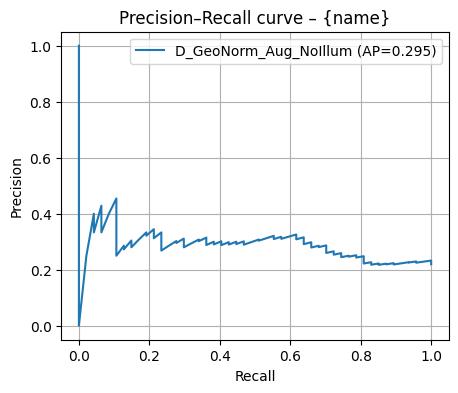

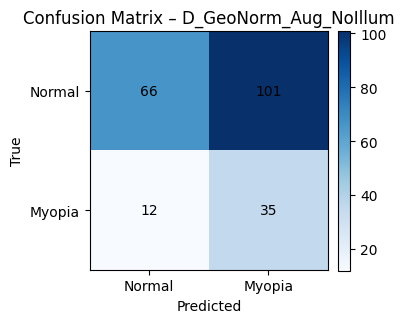

              precision    recall  f1-score   support

      Normal     0.8462    0.3952    0.5388       167
      Myopia     0.2574    0.7447    0.3825        47

    accuracy                         0.4720       214
   macro avg     0.5518    0.5699    0.4606       214
weighted avg     0.7168    0.4720    0.5045       214



,name,task,preprocessing_family,dropout,augmentation,normalization,best_val_auc,best_val_accuracy,test_auc,test_ap,test_accuracy@0.5,model_path
0,A_Raw_minimal,classification,SelectivePreproc,True,False,0-1,0.595257,0.781991,0.621735,0.326962,0.331776,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
1,B_GeoNorm,classification,SelectivePreproc,True,False,0-1,0.577668,0.753555,0.606319,0.277523,0.415888,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
2,C_GeoNorm_Illum_NoAug,classification,SelectivePreproc,True,False,0-1,0.564888,0.739336,0.604026,0.341337,0.257009,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
3,D_GeoNorm_Aug_NoIllum,classification,SelectivePreproc,True,True,0-1,0.571410,0.758294,0.603771,0.294837,0.471963,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...


In [13]:
results = []
models  = {}
histories = {}
datasets = {}

for exp in EXPERIMENTS:
    mdl, hist, metrics, ds_tuple = run_experiment(exp, epochs=10)

    name = exp["name"]
    models[name] = mdl
    histories[name] = hist
    datasets[name] = ds_tuple

    model_path = MODELS_DIR_SELECTIVE / f"small_cnn_classification_with_dropout_{name}.keras"
    mdl.save(model_path)

    results.append({
        "name": name,
        "task": "classification",
        "preprocessing_family": "SelectivePreproc",
        "dropout": True,
        "augmentation": exp["do_aug"],
        "normalization": exp["normalization"],
        "best_val_auc": float(np.max(hist.history.get("val_auc", [np.nan]))),
        "best_val_accuracy": float(np.max(hist.history.get("val_accuracy", [np.nan]))),
        "test_auc": metrics["AUC"],
        "test_ap": metrics["AP"],
        "test_accuracy@0.5": metrics["accuracy@0.5"],
        "model_path": str(model_path)
    })

results_df = pd.DataFrame(results)
results_df

The results table shows a comparative of the same model (small_cnn_classf) run over the 4 different sets of preprocessed pictures:
- best_val_auc: best AUC value (capacity of model to distinguish classes) obtained accross the 10 epochs on the **validation set** (1 perfect, 0.5 random)
- best_val_acc: best accuracy value (% of right guesses) obtained accross the 10 epochs on the **validation set** (watch out for unbalanced classes in dataset)
- test_auc: AUC obtained on **test set**. This might be the most important metric
- test_ap: average precision obtained on **test set** (area under precision-recall curve). Very useful with unbalanced classes since it focuses on performance on myopia class
- test_acc@0.5: accuracy obtained on **test set** when 0.5 threshold is applied (≥ 0.5 means myopia); < 0.5 means normal)

All in all:
- AUC shows how well the model distinguishes amongst classes
- Accuracy shows % of right guesses when classifying
- AP shows how well the model handles the minority class (looking at precision vs recall)

Note 1: if overfitting is seen we may increase the dropout rate, add L2 on Conv2D or increase augmentations.

Note 2: handling the smaller class (AP) can be complicated since, if there is a large picture number difference amongst classes, the model might learn to state it is almost always right to predict that a picture belongs to the larger group when classifying.

SCENARIOS COMPARISON 

The results show that the model has only **limited discriminative capacity** across all scenarios. The best test AUC is obtained by **A_Raw_minimal** with **AUC = 0.622**, followed by **B_GeoNorm** with **AUC = 0.606**, **C_GeoNorm_Illum_NoAug** with **AUC = 0.604**, and **D_GeoNorm_Aug_NoIllum** with **AUC = 0.604**. Therefore, all scenarios remain close to each other and only slightly above random classification.

The scenario with the best **Average Precision** is **C_GeoNorm_Illum_NoAug** with **AP = 0.341**, suggesting that illumination correction may help slightly when focusing on the minority class. However, this improvement in AP comes with a very low accuracy at the default threshold of 0.5.

The highest threshold-based accuracy is obtained by **D_GeoNorm_Aug_NoIllum** with **accuracy = 0.472**, but this is still clearly below the majority-class baseline of approximately **0.78**. This confirms that the default threshold is not well calibrated for these models, partly because class weights push the model towards predicting myopia more often.

The confusion matrices and classification reports show a common pattern: the model tends to detect many myopic images, but at the cost of producing many false positives among normal images. For example, scenario C reaches a very high myopia recall of **0.936**, but the normal recall drops to only **0.066**. In practical terms, this means that **the model classifies almost everything as myopia.**

-> Scenario A offers the best global ranking performance according to AUC and a relatively high myopia recall, but its accuracy is very low because it misclassifies many normal images as myopic. Scenario D gives the most balanced threshold-based behaviour, but its AUC and AP do not improve over the other scenarios.

Overall, no selective preprocessing scenario produces strong classification performance in this notebook. The results suggest that the model is able to extract a weak signal, but not enough to obtain reliable binary classification with the current architecture, Dropout configuration and threshold.

RESULTS TABLE

The results table shows that none of the selective preprocessing scenarios leads to strong classification performance with this model. The best validation AUC is obtained by **A_Raw_minimal** (**0.595**), and this same scenario also obtains the best test AUC (**0.622**). This makes A the best scenario if the priority is global class separability.

However, the best Average Precision is obtained by **C_GeoNorm_Illum_NoAug** (**0.341**). This suggests that applying geometry normalization and CLAHE may slightly help the model rank myopic samples, even though this does not translate into good fixed-threshold accuracy.

The best accuracy at threshold 0.5 is obtained by **D_GeoNorm_Aug_NoIllum** (**0.472**), but this value is still well below the majority-class baseline of approximately **0.78**. Therefore, the apparent improvement in accuracy for D should not be interpreted as strong classification performance.

In summary, the model is not robust enough in any of the four selective preprocessing scenarios. The results are useful mainly because they show that the classification problem remains difficult and that threshold-based accuracy is misleading in this imbalanced setting.


## 📊 4. Results

#### 📈 4.1 Plot histories
Plotting training and validation curves (AUC, accuracy, or loss) for Keras models, making it easy to compare performance across epochs.

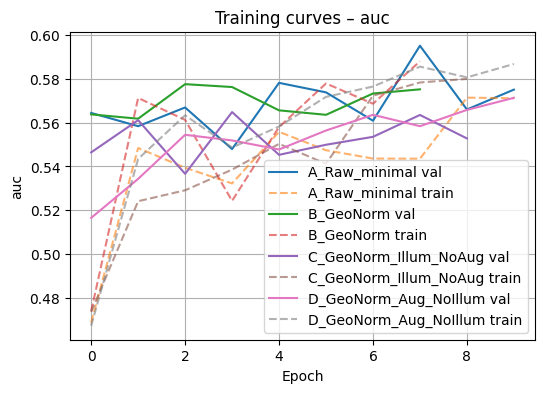

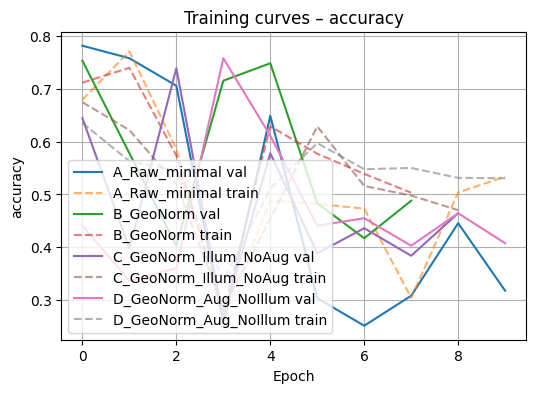

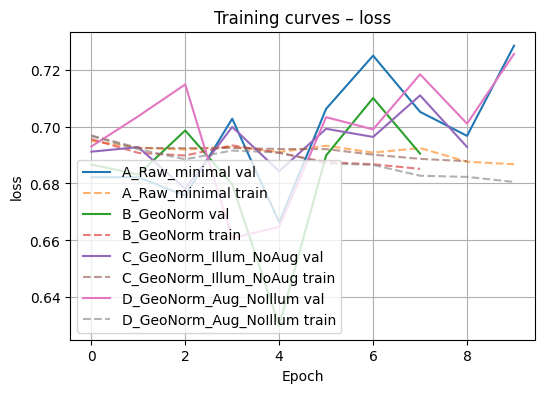

In [14]:
def plot_histories(histories_dict, metric="auc"):
    #histories: list of keras History objects
    #metric: "auc" | "accuracy" | "loss"

    plt.figure(figsize=(6,4))         # prefer validation metric if available
    for name, history in histories_dict.items():
        if f"val_{metric}" in history.history:
            plt.plot(history.history[f"val_{metric}"], label=f"{name} val")
        if metric in history.history:
            plt.plot(history.history[metric], linestyle="--", alpha=0.6,label=f"{name} train")

    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(f"Training curves – {metric}")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_histories(histories, metric="auc")
plot_histories(histories, metric="accuracy")
plot_histories(histories, metric="loss")

The training curves confirm the limited learning observed in the numerical results. Validation AUC remains in a narrow range, approximately between **0.55 and 0.60**, and does not show a clear upward trend. This indicates that the model does not progressively learn robust discriminative features for the validation data.

The training and validation loss values remain close to **0.69**, which is also consistent with a weak binary classifier. The accuracy curves are highly unstable and should be interpreted with caution because the dataset is imbalanced and the model is affected by class weighting.

There is no strong evidence of classical overfitting, since the training curves do not improve dramatically while validation worsens. Instead, the behaviour is closer to **underfitting or weak signal extraction**: the model struggles to learn a stable relationship between image appearance and myopia label.

The curves also show that the four preprocessing scenarios behave similarly. This supports the conclusion that, in this notebook, the choice between selective preprocessing scenarios does not radically change the model behaviour.


#### ⚖️ 4.2 Direct comparison A vs B vs C vs D on ROC & PR
This code evaluates multiple outcomes on the same test set, computes ROC and Precision–Recall curves (with AUC and AP), and overlays the curves to compare their performance directly.

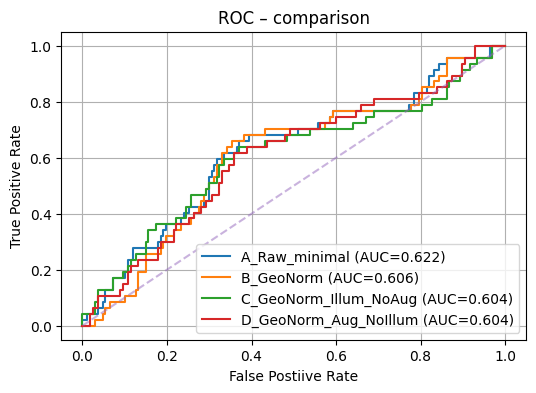

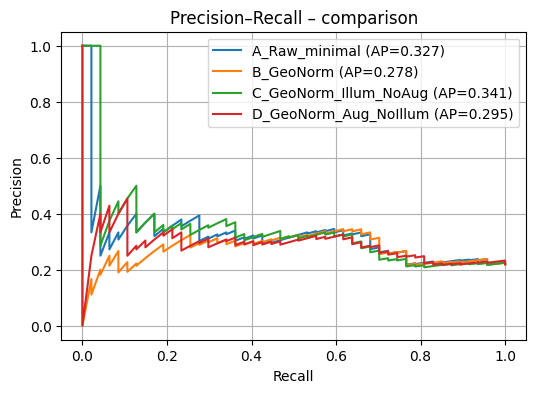

In [15]:
def compare_models_on_test(model_dict, scenario_splits, normalization="0-1"):
    
    curves = {}
    for name, mdl in model_dict.items():
        #csv_name = ALIAS_SPLITS.get(name, name)  #B for D patch
        test_csv = scenario_splits[name]["test"]  # created in run_experiment
        test_ds  = make_classification_ds(test_csv, training=False, normalization=normalization, do_aug=False)
        y_true, y_score = collect_preds(mdl, test_ds)
        fpr, tpr, _ = roc_curve(y_true, y_score)
        precision, recall, _ = precision_recall_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
        ap = average_precision_score(y_true, y_score)
        curves[name] = {"fpr":fpr,"tpr":tpr,"auc":roc_auc,"precision":precision,"recall":recall,"ap":ap}

    # ROC overlay
    plt.figure(figsize=(6,4))
    for name, d in curves.items():
        plt.plot(d["fpr"], d["tpr"], label=f"{name} (AUC={d['auc']:.3f})")
    plt.plot([0,1],[0,1],'--',alpha=0.5)
    plt.xlabel("False Postiive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC – comparison")
    plt.grid(True); plt.legend(); plt.show()

    # PR overlay
    plt.figure(figsize=(6,4))
    for name, d in curves.items():
        plt.plot(d["recall"], d["precision"], label=f"{name} (AP={d['ap']:.3f})")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title("Precision–Recall – comparison")
    plt.grid(True); plt.legend(); plt.show()

    return curves


classification_curves = compare_models_on_test(
    models,
    SCENARIO_SPLITS,
    normalization="0-1"
)

ROC and Precision-Recall comparison:

The ROC comparison shows that **A_Raw_minimal** obtains the highest AUC (**0.622**), but the difference with the other scenarios is small. All ROC curves remain relatively close to the diagonal reference line, confirming that the model separates the two classes only weakly.

The Precision-Recall comparison provides a slightly different perspective. **C_GeoNorm_Illum_NoAug** achieves the highest AP (**0.341**), followed by **A_Raw_minimal** (**0.327**), **D_GeoNorm_Aug_NoIllum** (**0.295**) and **B_GeoNorm** (**0.278**). Since myopia is the minority class, this suggests that the illumination-corrected scenario may be somewhat better at ranking myopic images earlier, even if its threshold-based accuracy is poor.

The PR curves remain low overall and close to the myopia prevalence baseline for much of the recall range. This means that, although the model sometimes detects myopic images, it does not do so with enough precision to be considered robust.

Therefore, the ROC and PR curves lead to a nuanced conclusion: **A_Raw_minimal is the best scenario by AUC**, while **C_GeoNorm_Illum_NoAug is the best scenario by AP**. However, neither result is strong enough to identify a clearly successful preprocessing strategy.


#### 📝 4.3 Conclusions

The dataset is imbalanced, with approximately **77% normal images** and **23% myopic images**. Because of this, accuracy is not the most reliable metric. A model predicting all samples as normal would reach approximately **0.78 accuracy** on the test set, so the much lower accuracies obtained by the trained models indicate that the default threshold is not well calibrated.

- The best scenario according to **test AUC** is **A_Raw_minimal**, with **AUC = 0.622**. This indicates that the simplest preprocessing setup provides the best global ranking between normal and myopic images, although the result is still only moderately above random.
- The best scenario according to **Average Precision** is **C_GeoNorm_Illum_NoAug**, with **AP = 0.341**. This suggests that geometry normalization plus illumination correction may help slightly when focusing on the minority class, but the improvement is not strong enough to make the model clinically reliable.
- The best scenario according to **accuracy at threshold 0.5** is **D_GeoNorm_Aug_NoIllum**, with **accuracy = 0.472**. However, this result remains far below the majority-class baseline, so it should not be interpreted as a good model. It only indicates that this scenario produces a slightly less extreme threshold behaviour.

The confusion matrices reveal that most scenarios tend to overpredict the myopic class. This is likely related to the use of class weights, which penalize errors on myopic images more strongly. As a consequence, the model improves myopia recall in some scenarios but produces many false positives among normal images.

Overall, this notebook shows that selective preprocessing with this small CNN and Dropout does not produce strong classification results. The model learns a weak signal, but not enough to separate normal and myopic images reliably. These findings justify testing alternative configurations in later notebooks, especially models without Dropout, transfer learning approaches, or more advanced preprocessing and threshold calibration strategies.

ALL IN ALL:

When the small CNN with Dropout was trained on selectively preprocessed images, the four preprocessing scenarios produced similar and limited results. The best AUC was obtained with raw-minimal preprocessing, while the best Average Precision was obtained with geometry normalization plus CLAHE. However, all models remained close to random-to-moderate discrimination and showed poor threshold-based accuracy due to the strong class imbalance and the tendency to overpredict myopia. Therefore, selective preprocessing did not provide a clear improvement over the full preprocessing approach in this configuration.


End :)